In [1]:
!pip install catboost xgboost openpyxl -q
!pip install iterative-stratification
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00


In [2]:


import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    make_scorer,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


HAS_XGBOOST = True
HAS_CATBOOST = True
HAS_LIGHTGBM = True

try:
    from xgboost import XGBClassifier
except Exception:
    HAS_XGBOOST = False
    print("XGBoost not installed. Skipping XGBoost model.")

try:
    from catboost import CatBoostClassifier
except Exception:
    HAS_CATBOOST = False
    print("CatBoost not installed. Skipping CatBoost model.")

try:
    from lightgbm import LGBMClassifier
except Exception:
    HAS_LIGHTGBM = False
    print("LightGBM not installed. Skipping LightGBM model.")




Defines custom weighted classifiers and an ordinal regressor wrapper to handle class imbalance and compare multiple approaches for multiclass priority prediction.

In [3]:

class WeightedHistGBClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.05, max_depth=5, max_iter=250, random_state=42):
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = HistGradientBoostingClassifier(
            learning_rate=self.learning_rate,
            max_depth=self.max_depth,
            max_iter=self.max_iter,
            random_state=self.random_state
        )
        sw = compute_sample_weight(class_weight="balanced", y=y)
        self.model_.fit(X, y, sample_weight=sw)
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


class WeightedXGBClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.random_state = random_state
        self.n_jobs = n_jobs

    def fit(self, X, y):
        self.model_ = XGBClassifier(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            learning_rate=self.learning_rate,
            subsample=self.subsample,
            colsample_bytree=self.colsample_bytree,
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=self.random_state,
            n_jobs=self.n_jobs
        )
        sw = compute_sample_weight(class_weight="balanced", y=y)
        self.model_.fit(X, y, sample_weight=sw)
        self.classes_ = np.array([0, 1, 2])
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


class WeightedLGBMClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1
    ):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.num_leaves = num_leaves
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.random_state = random_state
        self.n_jobs = n_jobs

    def fit(self, X, y):
        self.model_ = LGBMClassifier(
            objective="multiclass",
            num_class=3,
            n_estimators=self.n_estimators,
            learning_rate=self.learning_rate,
            num_leaves=self.num_leaves,
            subsample=self.subsample,
            colsample_bytree=self.colsample_bytree,
            class_weight="balanced",
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            verbosity=-1
        )
        self.model_.fit(X, y)
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


class OrdinalRegressorClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.05, max_depth=5, max_iter=250, random_state=42):
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = HistGradientBoostingRegressor(
            learning_rate=self.learning_rate,
            max_depth=self.max_depth,
            max_iter=self.max_iter,
            random_state=self.random_state
        )
        sw = compute_sample_weight(class_weight="balanced", y=y)
        self.model_.fit(X, y.astype(float), sample_weight=sw)
        self.classes_ = np.array([0, 1, 2])
        return self

    def predict(self, X):
        pred_score = self.model_.predict(X)
        pred_class = np.clip(np.round(pred_score), 0, 2).astype(int)
        return pred_class

    def predict_proba(self, X):
        pred_score = self.model_.predict(X)
        centers = np.array([0.0, 1.0, 2.0])
        dists = np.abs(pred_score.reshape(-1, 1) - centers.reshape(1, -1))
        sim = 1 / (1 + dists)
        proba = sim / sim.sum(axis=1, keepdims=True)
        return proba




Loads the priority dataset and displays its size and column names.

In [4]:



input_path = "Priority_Dataset.csv"
df = pd.read_csv(input_path)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Dataset shape: (3000, 40)

Columns: ['id', 'disaster_type', 'num_people', 'duration_band', 'children', 'elderly', 'pregnant', 'disability', 'water_rising_flag', 'near_submerged_flag', 'landslide_active_risk_flag', 'cyclone_active_risk_flag', 'trapped', 'medical_urgency_flag', 'access_blocked', 'river_overflow_flag', 'river_near_flag', 'building_damage_flag', 'mass_impact_flag', 'vulnerability_flag', 'final_escape_level_flag', 't_hours', 'T_score', 'V_score', 'M_score', 'G_score', 'R', 'W_score', 'L_score', 'C_score', 'B_score', 'Ro_score', 'Rn_score', 'E_raw', 'E', 'S_t', 'F', 'priority_score', 'priority_label', 'priority_class']


Cleans the target labels, removes invalid and duplicate rows, converts priority classes into numeric values, and prints the class distribution.

In [5]:

TARGET = "priority_label"
label_order = ["Low", "Moderate", "Critical"]
label_to_int = {"Low": 0, "Moderate": 1, "Critical": 2}
int_to_label = {v: k for k, v in label_to_int.items()}

df = df.dropna(how="all").copy()
df.columns = df.columns.str.strip()
df[TARGET] = df[TARGET].astype(str).str.strip().str.title()

print("\nRaw target distribution before filtering:")
print(df[TARGET].value_counts(dropna=False))

df = df[df[TARGET].isin(label_order)].copy()

duplicates = df.duplicated().sum()
print("\nDuplicate rows found:", duplicates)
if duplicates > 0:
    df = df.drop_duplicates().copy()
    print("Duplicates removed")

y = df[TARGET].map(label_to_int).astype(int)

print("\nTarget mapping:")
for k, v in label_to_int.items():
    print(f"{k} -> {v}")

print("\nTarget distribution:")
print(y.value_counts().sort_index())




Raw target distribution before filtering:
priority_label
Low         1903
Moderate     914
Critical     183
Name: count, dtype: int64

Duplicate rows found: 0

Target mapping:
Low -> 0
Moderate -> 1
Critical -> 2

Target distribution:
priority_label
0    1903
1     914
2     183
Name: count, dtype: int64


Removes target and leakage-related columns, then selects the remaining input features for model training.

In [6]:

drop_cols = [
    TARGET, "priority_class", "priority_y", "y", "priority_score",
    "t_hours", "T_score", "V_score", "M_score", "G_score",
    "R", "W_score", "L_score", "C_score", "B_score", "Ro_score", "Rn_score",
    "E_raw", "E", "S_t", "F", "id"
]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols, errors="ignore").copy()

print("\nFeature columns used for ML:")
print(X.columns.tolist())




Feature columns used for ML:
['disaster_type', 'num_people', 'duration_band', 'children', 'elderly', 'pregnant', 'disability', 'water_rising_flag', 'near_submerged_flag', 'landslide_active_risk_flag', 'cyclone_active_risk_flag', 'trapped', 'medical_urgency_flag', 'access_blocked', 'river_overflow_flag', 'river_near_flag', 'building_damage_flag', 'mass_impact_flag', 'vulnerability_flag', 'final_escape_level_flag']


Separates the input features into categorical and numeric columns for preprocessing.

In [7]:

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

print("\nCategorical columns:", cat_cols)
print("Numeric columns:", num_cols)




Categorical columns: ['disaster_type', 'duration_band']
Numeric columns: ['num_people', 'children', 'elderly', 'pregnant', 'disability', 'water_rising_flag', 'near_submerged_flag', 'landslide_active_risk_flag', 'cyclone_active_risk_flag', 'trapped', 'medical_urgency_flag', 'access_blocked', 'river_overflow_flag', 'river_near_flag', 'building_damage_flag', 'mass_impact_flag', 'vulnerability_flag', 'final_escape_level_flag']


Builds separate preprocessing pipelines for linear, tree-based, and CatBoost models, then checks the prepared feature data before training.

In [8]:

linear_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

tree_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess_linear = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_cols),
        ("num", linear_numeric_transformer, num_cols)
    ],
    remainder="drop"
)

preprocess_tree = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_cols),
        ("num", tree_numeric_transformer, num_cols)
    ],
    remainder="drop"
)


X_catboost = X.copy()
for c in cat_cols:
    X_catboost[c] = X_catboost[c].astype(str).fillna("missing")
for c in num_cols:
    X_catboost[c] = pd.to_numeric(X_catboost[c], errors="coerce")

cat_feature_indices = [X_catboost.columns.get_loc(c) for c in cat_cols]


print("Categorical columns:")
print(cat_cols)

print("\nNumeric columns:")
print(num_cols)

print("\nX shape before preprocessing:", X.shape)

print("\nFirst 5 rows of X:")
print(X.head())

print("\nMissing values in categorical columns:")
print(X[cat_cols].isnull().sum())

print("\nMissing values in numeric columns:")
print(X[num_cols].isnull().sum())

print("\nCatBoost data types:")
print(X_catboost.dtypes)

print("\nFirst 5 rows of X_catboost:")
print(X_catboost.head())

print("\nCategorical feature indices for CatBoost:")
print(cat_feature_indices)



Categorical columns:
['disaster_type', 'duration_band']

Numeric columns:
['num_people', 'children', 'elderly', 'pregnant', 'disability', 'water_rising_flag', 'near_submerged_flag', 'landslide_active_risk_flag', 'cyclone_active_risk_flag', 'trapped', 'medical_urgency_flag', 'access_blocked', 'river_overflow_flag', 'river_near_flag', 'building_damage_flag', 'mass_impact_flag', 'vulnerability_flag', 'final_escape_level_flag']

X shape before preprocessing: (3000, 20)

First 5 rows of X:
  disaster_type  num_people duration_band  children  elderly  pregnant  \
0         flood           8          >24h         0        0         0   
1     landslide           3         6-12h         0        0         0   
2         flood          20          >24h         0        0         0   
3       tsunami          15        12-24h         1        0         1   
4       cyclone          20         <1-6h         0        0         0   

   disability  water_rising_flag  near_submerged_flag  \
0       

Generates exploratory charts to visualize class balance, missing data, disaster patterns, feature distributions, and numeric correlations in the priority dataset.


Generating dataset charts...


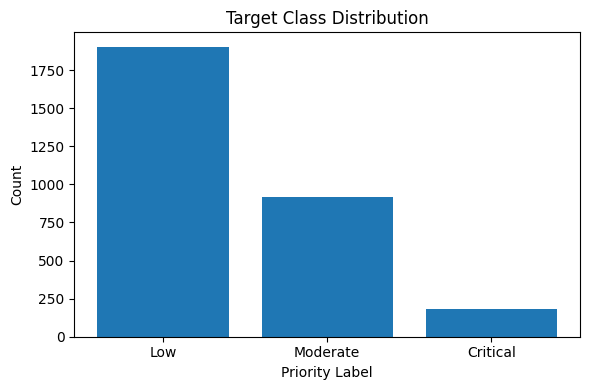

No missing values found.


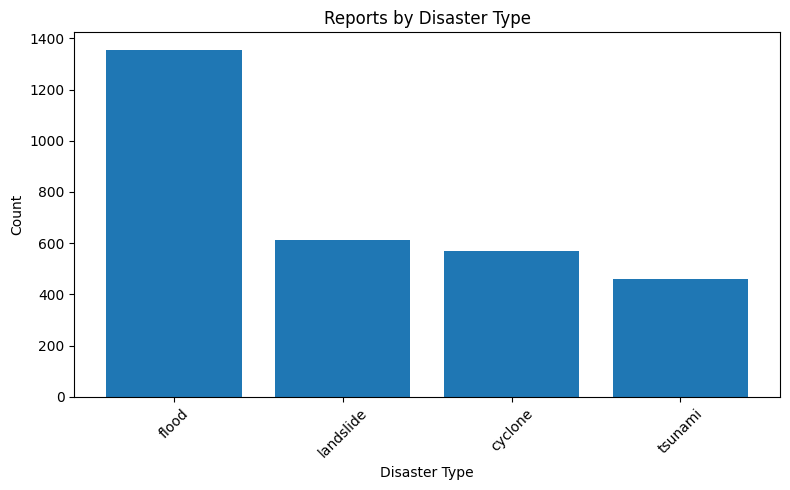

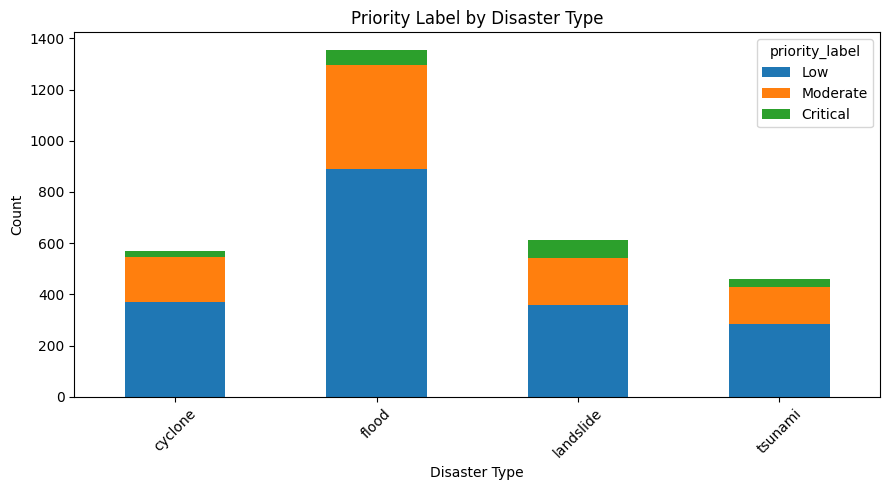

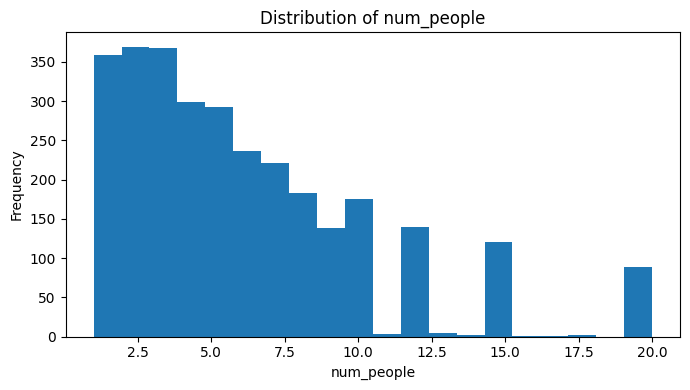

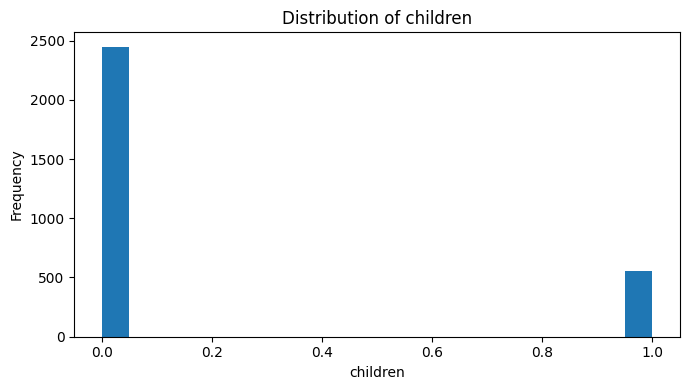

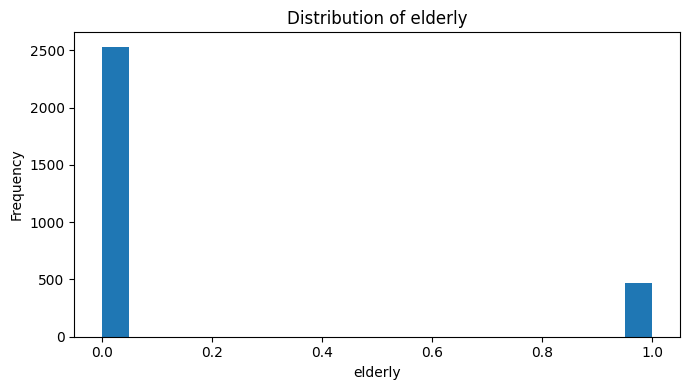

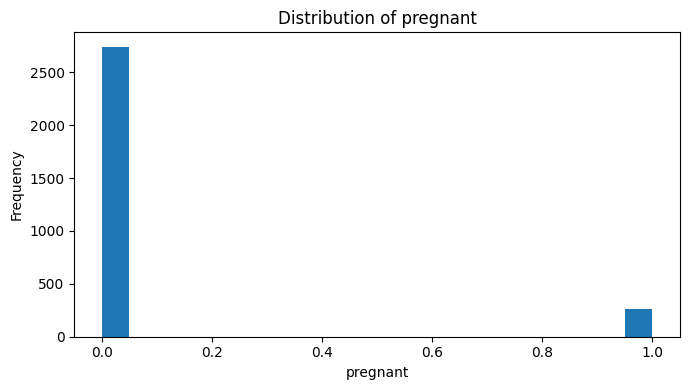

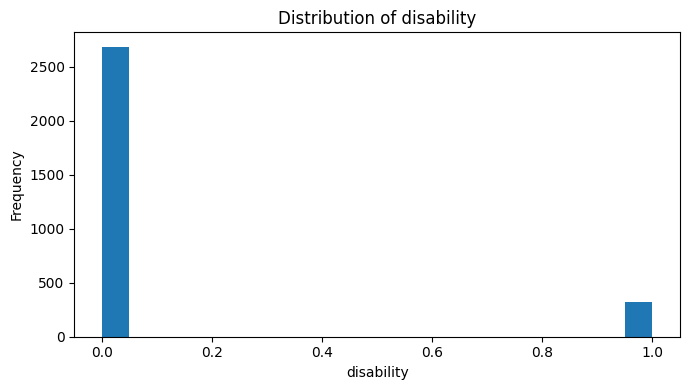

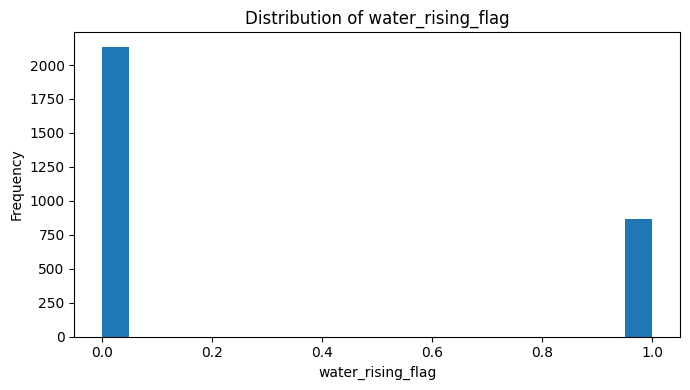

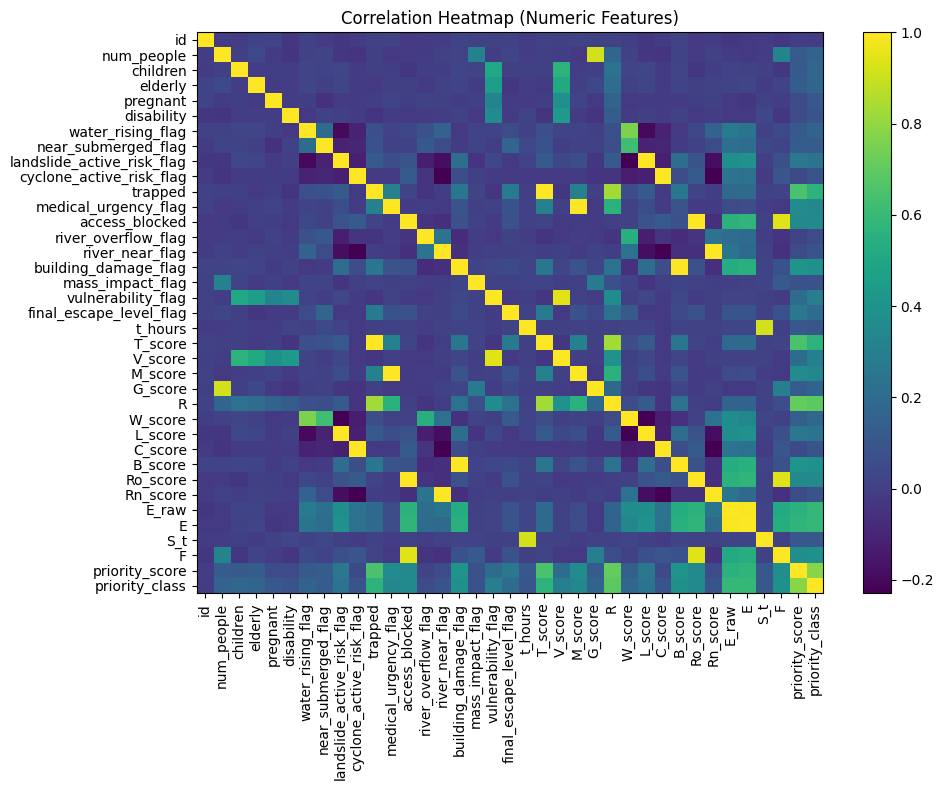

In [9]:

print("\nGenerating dataset charts...")

# 6.1 Target distribution
target_counts = df[TARGET].value_counts().reindex(label_order)

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index, target_counts.values)
plt.title("Target Class Distribution")
plt.xlabel("Priority Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("chart_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 6.2 Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    plt.figure(figsize=(8, 5))
    plt.barh(missing.index[::-1], missing.values[::-1])
    plt.title("Missing Values per Column")
    plt.xlabel("Missing Count")
    plt.tight_layout()
    plt.savefig("chart_missing_values.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No missing values found.")

# 6.3 Disaster type distribution
if "disaster_type" in df.columns:
    disaster_counts = df["disaster_type"].astype(str).str.strip().value_counts()

    plt.figure(figsize=(8, 5))
    plt.bar(disaster_counts.index, disaster_counts.values)
    plt.title("Reports by Disaster Type")
    plt.xlabel("Disaster Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("chart_disaster_type_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

# 6.4 Priority by disaster type
if "disaster_type" in df.columns:
    cross_tab = pd.crosstab(df["disaster_type"], df[TARGET])
    cross_tab = cross_tab.reindex(columns=label_order, fill_value=0)

    cross_tab.plot(kind="bar", stacked=True, figsize=(9, 5))
    plt.title("Priority Label by Disaster Type")
    plt.xlabel("Disaster Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("chart_priority_by_disaster_type.png", dpi=300, bbox_inches="tight")
    plt.show()

# 6.5 Numeric feature distributions
if len(num_cols) > 0:
    top_num_cols = num_cols[:6]
    for col in top_num_cols:
        plt.figure(figsize=(7, 4))
        clean_series = pd.to_numeric(df[col], errors="coerce").dropna()
        if len(clean_series) > 0:
            plt.hist(clean_series, bins=20)
            plt.title(f"Distribution of {col}")
            plt.xlabel(col)
            plt.ylabel("Frequency")
            plt.tight_layout()
            safe_name = str(col).replace("/", "_").replace(" ", "_")
            plt.savefig(f"dist_{safe_name}.png", dpi=300, bbox_inches="tight")
            plt.show()

# 6.6 Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] > 1:
    corr = numeric_df.corr()

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout()
    plt.savefig("chart_correlation_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()



Splits the priority dataset into stratified train, validation, and test sets, then visualizes the class distribution across those splits.


Train shape: (1920, 20)
Validation shape: (480, 20)
Test shape: (600, 20)


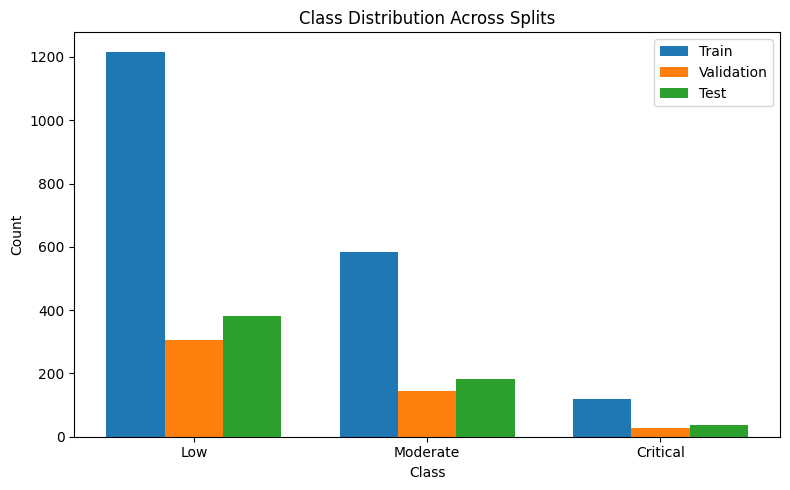

In [10]:

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, stratify=y_train_full, random_state=42
)

X_train_full_cb, X_test_cb, y_train_full_cb, y_test_cb = train_test_split(
    X_catboost, y, test_size=0.20, stratify=y, random_state=42
)

X_train_cb, X_val_cb, y_train_cb, y_val_cb = train_test_split(
    X_train_full_cb, y_train_full_cb, test_size=0.20, stratify=y_train_full_cb, random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# 7.1 Split distribution chart
train_counts = y_train.value_counts().sort_index().reindex([0, 1, 2], fill_value=0)
val_counts = y_val.value_counts().sort_index().reindex([0, 1, 2], fill_value=0)
test_counts = y_test.value_counts().sort_index().reindex([0, 1, 2], fill_value=0)

x = np.arange(len(label_order))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, train_counts.values, width=width, label="Train")
plt.bar(x, val_counts.values, width=width, label="Validation")
plt.bar(x + width, test_counts.values, width=width, label="Test")
plt.xticks(x, label_order)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution Across Splits")
plt.legend()
plt.tight_layout()
plt.savefig("chart_split_distribution.png", dpi=300, bbox_inches="tight")
plt.show()



Defines multiple balanced and calibrated classification pipelines to compare different models for priority prediction.

In [11]:

models = {
    "LogisticRegression_balanced": Pipeline([
        ("prep", preprocess_linear),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "LogisticRegression_calibrated": Pipeline([
        ("prep", preprocess_linear),
        ("clf", CalibratedClassifierCV(
            estimator=LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42
            ),
            method="sigmoid",
            cv=3
        ))
    ]),

    "RandomForest_balanced": Pipeline([
        ("prep", preprocess_tree),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "RandomForest_calibrated": Pipeline([
        ("prep", preprocess_tree),
        ("clf", CalibratedClassifierCV(
            estimator=RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            ),
            method="sigmoid",
            cv=3
        ))
    ]),

    "ExtraTrees_balanced": Pipeline([
        ("prep", preprocess_tree),
        ("clf", ExtraTreesClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "HistGradientBoosting_weighted": Pipeline([
        ("prep", preprocess_tree),
        ("clf", WeightedHistGBClassifier(
            learning_rate=0.05,
            max_depth=5,
            max_iter=250,
            random_state=42
        ))
    ]),

    "Ordinal_HistGradientBoosting": Pipeline([
        ("prep", preprocess_tree),
        ("clf", OrdinalRegressorClassifier(
            learning_rate=0.05,
            max_depth=5,
            max_iter=250,
            random_state=42
        ))
    ]),
}

if HAS_XGBOOST:
    models["XGBoost_weighted"] = Pipeline([
        ("prep", preprocess_tree),
        ("clf", WeightedXGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            n_jobs=-1
        ))
    ])

if HAS_LIGHTGBM:
    models["LightGBM_weighted"] = Pipeline([
        ("prep", preprocess_tree),
        ("clf", WeightedLGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            n_jobs=-1
        ))
    ])

print("\nModels to compare:")
for m in models.keys():
    print("-", m)




Models to compare:
- LogisticRegression_balanced
- LogisticRegression_calibrated
- RandomForest_balanced
- RandomForest_calibrated
- ExtraTrees_balanced
- HistGradientBoosting_weighted
- Ordinal_HistGradientBoosting
- XGBoost_weighted
- LightGBM_weighted


Performs grid-search hyperparameter tuning for each candidate model and keeps the best version of each for final comparison.

In [12]:

print("\nStarting hyperparameter tuning for all models...")

tuned_models = {}

param_grids = {
    "LogisticRegression_balanced": {
        "clf__C": [0.1, 1.0, 5.0],
        "clf__solver": ["lbfgs", "liblinear"]
    },

    "LogisticRegression_calibrated": {
        "clf__estimator__C": [0.1, 1.0, 5.0],
        "clf__estimator__solver": ["lbfgs", "liblinear"],
        "clf__method": ["sigmoid"]
    },

    "RandomForest_balanced": {
        "clf__n_estimators": [200, 500],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_leaf": [1, 2, 4]
    },

    "RandomForest_calibrated": {
        "clf__estimator__n_estimators": [200, 500],
        "clf__estimator__max_depth": [None, 10, 20],
        "clf__estimator__min_samples_leaf": [1, 2, 4],
        "clf__method": ["sigmoid"]
    },

    "ExtraTrees_balanced": {
        "clf__n_estimators": [200, 500],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_leaf": [1, 2, 4]
    },

    "HistGradientBoosting_weighted": {
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__max_depth": [3, 5, 7],
        "clf__max_iter": [150, 250, 350]
    },

    "Ordinal_HistGradientBoosting": {
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__max_depth": [3, 5, 7],
        "clf__max_iter": [150, 250, 350]
    }
}

if HAS_XGBOOST and "XGBoost_weighted" in models:
    param_grids["XGBoost_weighted"] = {
        "clf__n_estimators": [200, 300, 400],
        "clf__max_depth": [3, 5, 7],
        "clf__learning_rate": [0.01, 0.05, 0.1]
    }

if HAS_LIGHTGBM and "LightGBM_weighted" in models:
    param_grids["LightGBM_weighted"] = {
        "clf__n_estimators": [200, 300, 400],
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__num_leaves": [31, 50, 70]
    }

for model_name, pipeline in models.items():
    print(f"\nTuning {model_name}...")

    if model_name not in param_grids:
        print(f"No param grid found for {model_name}. Keeping original model.")
        tuned_models[model_name] = pipeline
        continue

    try:
        gs = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[model_name],
            scoring="f1_macro",
            cv=3,
            n_jobs=-1,
            error_score="raise"
        )

        gs.fit(X_train, y_train)
        tuned_models[model_name] = gs.best_estimator_

        print(f"{model_name} tuned successfully.")
        print("Best params:", gs.best_params_)
        print("Best CV score:", gs.best_score_)

    except Exception as e:
        print(f"{model_name} tuning failed: {e}")
        print("Using original model instead.")
        tuned_models[model_name] = pipeline


models = tuned_models.copy()

print("\nHyperparameter tuning complete. Updated models ready for CV.")
print("\nFinal tuned models:")
for m in models.keys():
    print("-", m)


Starting hyperparameter tuning for all models...

Tuning LogisticRegression_balanced...
LogisticRegression_balanced tuned successfully.
Best params: {'clf__C': 5.0, 'clf__solver': 'lbfgs'}
Best CV score: 0.8816060790439355

Tuning LogisticRegression_calibrated...
LogisticRegression_calibrated tuned successfully.
Best params: {'clf__estimator__C': 1.0, 'clf__estimator__solver': 'lbfgs', 'clf__method': 'sigmoid'}
Best CV score: 0.8583232653948398

Tuning RandomForest_balanced...
RandomForest_balanced tuned successfully.
Best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 500}
Best CV score: 0.8404302638526394

Tuning RandomForest_calibrated...
RandomForest_calibrated tuned successfully.
Best params: {'clf__estimator__max_depth': None, 'clf__estimator__min_samples_leaf': 2, 'clf__estimator__n_estimators': 200, 'clf__method': 'sigmoid'}
Best CV score: 0.8365977057284638

Tuning ExtraTrees_balanced...
ExtraTrees_balanced tuned successfully.
Best params: {

Runs 5-fold stratified cross-validation to compare all candidate priority models, select the best one, save the results, and visualize model performance across key metrics.


RUNNING 5-FOLD CV ON TRAIN SET
LogisticRegression_balanced done.
LogisticRegression_calibrated done.
RandomForest_balanced done.
RandomForest_calibrated done.
ExtraTrees_balanced done.
HistGradientBoosting_weighted done.
Ordinal_HistGradientBoosting done.
XGBoost_weighted done.
LightGBM_weighted done.

Running CatBoost native CV...

CV RESULTS
                           model  accuracy_mean  balanced_acc_mean  \
0               XGBoost_weighted       0.929167           0.895927   
1  HistGradientBoosting_weighted       0.926042           0.902505   
2   Ordinal_HistGradientBoosting       0.913542           0.896444   
3    LogisticRegression_balanced       0.908854           0.902012   
4       CatBoost_native_balanced       0.913542           0.888612   
5              LightGBM_weighted       0.916667           0.868466   
6  LogisticRegression_calibrated       0.886458           0.864899   
7          RandomForest_balanced       0.897396           0.842630   
8        RandomForest_c

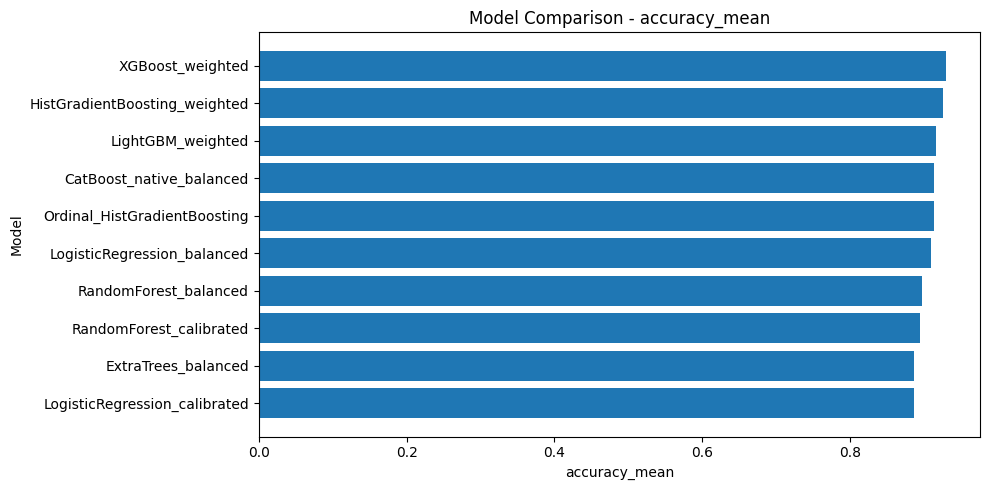

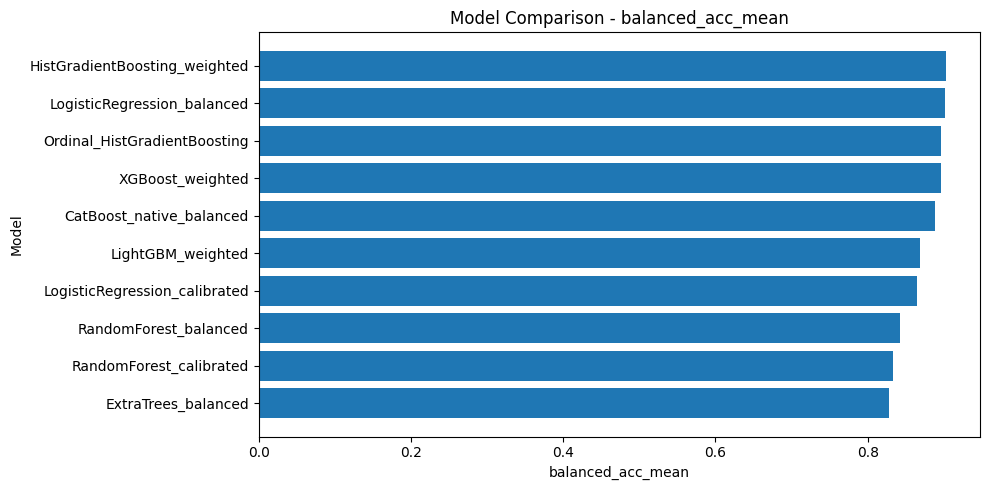

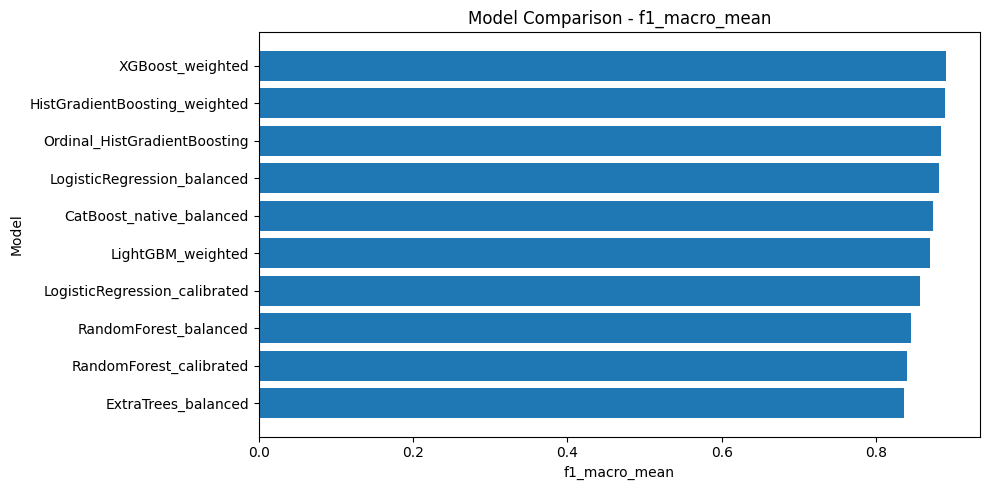

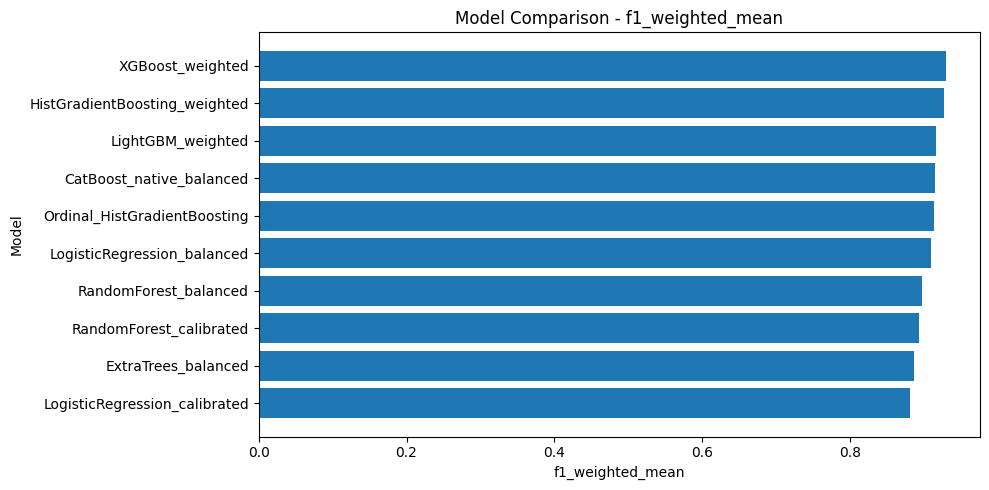

In [13]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "balanced_acc": "balanced_accuracy",
    "f1_macro": make_scorer(f1_score, average="macro"),
    "f1_weighted": make_scorer(f1_score, average="weighted")
}

rows = []
print("\n" + "=" * 80)
print("RUNNING 5-FOLD CV ON TRAIN SET")

for name, pipe in models.items():
    try:
        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            error_score="raise"
        )

        rows.append({
            "model": name,
            "accuracy_mean": scores["test_accuracy"].mean(),
            "balanced_acc_mean": scores["test_balanced_acc"].mean(),
            "f1_macro_mean": scores["test_f1_macro"].mean(),
            "f1_weighted_mean": scores["test_f1_weighted"].mean()
        })

        print(f"{name} done.")

    except Exception as e:
        print(f"{name} failed: {e}")

catboost_cv_row = None
if HAS_CATBOOST:
    print("\nRunning CatBoost native CV...")
    fold_acc = []
    fold_bal = []
    fold_macro = []
    fold_weighted = []

    for tr_idx, va_idx in cv.split(X_train_cb, y_train_cb):
        X_tr = X_train_cb.iloc[tr_idx]
        y_tr = y_train_cb.iloc[tr_idx]
        X_va = X_train_cb.iloc[va_idx]
        y_va = y_train_cb.iloc[va_idx]

        cb = CatBoostClassifier(
            iterations=300,
            depth=6,
            learning_rate=0.05,
            loss_function="MultiClass",
            auto_class_weights="Balanced",
            verbose=0,
            random_seed=42
        )

        cb.fit(X_tr, y_tr, cat_features=cat_feature_indices)
        pred = cb.predict(X_va).reshape(-1).astype(int)

        fold_acc.append(accuracy_score(y_va, pred))
        fold_bal.append(balanced_accuracy_score(y_va, pred))
        fold_macro.append(f1_score(y_va, pred, average="macro"))
        fold_weighted.append(f1_score(y_va, pred, average="weighted"))

    catboost_cv_row = {
        "model": "CatBoost_native_balanced",
        "accuracy_mean": np.mean(fold_acc),
        "balanced_acc_mean": np.mean(fold_bal),
        "f1_macro_mean": np.mean(fold_macro),
        "f1_weighted_mean": np.mean(fold_weighted)
    }
    rows.append(catboost_cv_row)

results_df = pd.DataFrame(rows).sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)

print("\nCV RESULTS")
print(results_df)

best_model_name = results_df.iloc[0]["model"]
print("\nBest model from CV:", best_model_name)

# 9.1 Save CV results
results_df.to_csv("model_comparison_results_3stage.csv", index=False)
print("Model comparison saved to: model_comparison_results_3stage.csv")

# 9.2 Model comparison charts
metrics = ["accuracy_mean", "balanced_acc_mean", "f1_macro_mean", "f1_weighted_mean"]

for metric in metrics:
    plt.figure(figsize=(10, 5))
    ordered = results_df.sort_values(metric, ascending=True)
    plt.barh(ordered["model"], ordered[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.xlabel(metric)
    plt.ylabel("Model")
    plt.tight_layout()
    plt.savefig(f"chart_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()



Fits the best-performing priority model on the training data using the appropriate training method for either CatBoost or sklearn.

In [14]:
print("Best model:", best_model_name)

if best_model_name == "CatBoost_native_balanced":
    best_pipe = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="MultiClass",
        auto_class_weights="Balanced",
        verbose=0,
        random_seed=42
    )
    print("Fitting CatBoost on:", X_train_cb.shape, y_train_cb.shape)
    best_pipe.fit(X_train_cb, y_train_cb, cat_features=cat_feature_indices)
    best_is_catboost_native = True
else:
    best_pipe = clone(models[best_model_name])
    print("Fitting sklearn model on:", X_train.shape, y_train.shape)
    best_pipe.fit(X_train, y_train)
    best_is_catboost_native = False

print("Fit complete.")

Best model: XGBoost_weighted
Fitting sklearn model on: (1920, 20) (1920,)
Fit complete.


Searches for the best class-specific probability scaling factors on the validation set to improve macro F1 and reduce class imbalance bias.

In [15]:

def apply_class_scalers(proba, scalers):
    adjusted = proba * np.array(scalers)
    return adjusted.argmax(axis=1)

def search_best_scalers_from_proba(proba, y_val):
    best_score = -1
    best_scalers = [1.0, 1.0, 1.0]

    moderate_grid = [1.0, 1.05, 1.1, 1.2, 1.3]
    critical_grid = [1.0, 1.1, 1.2, 1.3, 1.5]

    for m in moderate_grid:
        for c in critical_grid:
            scalers = [1.0, m, c]
            pred = apply_class_scalers(proba, scalers)
            score = f1_score(y_val, pred, average="macro")
            if score > best_score:
                best_score = score
                best_scalers = scalers

    return best_scalers, best_score

if best_is_catboost_native:
    val_proba = best_pipe.predict_proba(X_val_cb)
    best_scalers, best_val_macro_f1 = search_best_scalers_from_proba(val_proba, y_val_cb)
else:
    if hasattr(best_pipe, "predict_proba"):
        val_proba = best_pipe.predict_proba(X_val)
        best_scalers, best_val_macro_f1 = search_best_scalers_from_proba(val_proba, y_val)
    else:
        best_scalers = [1.0, 1.0, 1.0]
        best_val_macro_f1 = None

print("\nBest class scalers:", best_scalers)
print("Best validation macro F1:", best_val_macro_f1)




Best class scalers: [1.0, 1.2, 1.0]
Best validation macro F1: 0.8854744448629307


Defines visualization functions to compare raw and scaled class probabilities and to show how scaling changes the confusion matrix.

In [16]:

def plot_raw_vs_scaled(proba, scalers, label_names, sample_idx=0):
    raw = proba[sample_idx]
    scaled = raw * np.array(scalers)

    x = np.arange(len(label_names))
    width = 0.35

    plt.figure(figsize=(6, 4))
    plt.bar(x - width/2, raw, width, label="Raw")
    plt.bar(x + width/2, scaled, width, label="Scaled")

    plt.xticks(x, label_names)
    plt.ylabel("Probability")
    plt.title(f"Raw vs Scaled Risk (Sample {sample_idx})")
    plt.legend()
    plt.tight_layout()
    plt.show()


def compare_confusion_matrices(y_true, raw_proba, scalers, labels):

    raw_pred = raw_proba.argmax(axis=1)
    scaled_pred = (raw_proba * scalers).argmax(axis=1)

    cm_raw = confusion_matrix(y_true, raw_pred)
    cm_scaled = confusion_matrix(y_true, scaled_pred)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    ConfusionMatrixDisplay(cm_raw, display_labels=labels).plot(ax=axes[0])
    axes[0].set_title("Raw")

    ConfusionMatrixDisplay(cm_scaled, display_labels=labels).plot(ax=axes[1])
    axes[1].set_title("Scaled")

    plt.tight_layout()
    plt.show()

Generates final test predictions, visualizes raw versus scaled outputs, and evaluates the final priority model using classification metrics and a detailed report.


Visualizing Raw vs Scaled Risk...


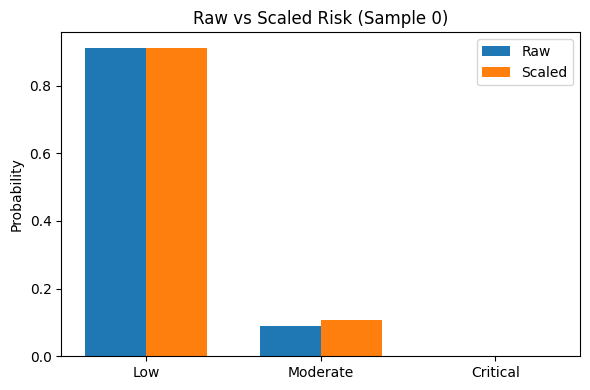

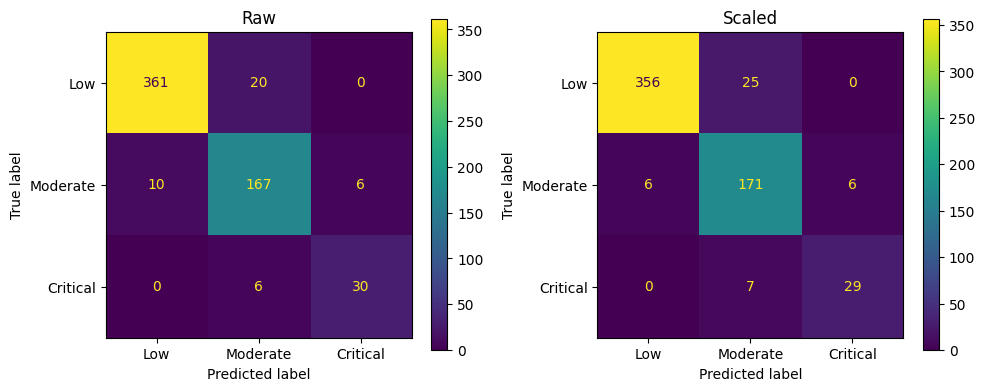


TEST RESULTS
Accuracy: 0.9267
Balanced Accuracy: 0.8915
F1 Macro: 0.8871
F1 Weighted: 0.9278

Classification Report
              precision    recall  f1-score   support

         Low       0.98      0.93      0.96       381
    Moderate       0.84      0.93      0.89       183
    Critical       0.83      0.81      0.82        36

    accuracy                           0.93       600
   macro avg       0.88      0.89      0.89       600
weighted avg       0.93      0.93      0.93       600



In [17]:

if best_is_catboost_native:
    test_proba = best_pipe.predict_proba(X_test_cb)
    y_pred = apply_class_scalers(test_proba, best_scalers)
    y_test_eval = y_test_cb
else:
    if hasattr(best_pipe, "predict_proba"):
        test_proba = best_pipe.predict_proba(X_test)
        y_pred = apply_class_scalers(test_proba, best_scalers)
    else:
        y_pred = best_pipe.predict(X_test)
        test_proba = None
    y_test_eval = y_test

if test_proba is not None:
    print("\nVisualizing Raw vs Scaled Risk...")

    # 1. Single sample comparison
    plot_raw_vs_scaled(test_proba, best_scalers, label_order, sample_idx=0)

    # 2. Confusion matrix comparison
    compare_confusion_matrices(y_test_eval, test_proba, best_scalers, label_order)

print("\n" + "=" * 80)
print("TEST RESULTS")
print(f"Accuracy: {accuracy_score(y_test_eval, y_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_eval, y_pred):.4f}")
print(f"F1 Macro: {f1_score(y_test_eval, y_pred, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test_eval, y_pred, average='weighted'):.4f}")

print("\nClassification Report")
report_text = classification_report(
    y_test_eval,
    y_pred,
    labels=[0, 1, 2],
    target_names=label_order,
    zero_division=0
)
print(report_text)



Defines a prediction function that preprocesses new input data, generates class probabilities, applies class scaling, and returns the final priority prediction.

In [18]:

def predict_priority(new_df, model, preprocess=None, cat_features=None, scalers=[1.0, 1.0, 1.0]):


    if hasattr(model, "predict_proba") and preprocess is not None:
        X_proc = preprocess.transform(new_df)
    else:
        X_proc = new_df.copy()

    if cat_features is not None and hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_proc)
    else:
        proba = model.predict_proba(X_proc) if hasattr(model, "predict_proba") else model.predict(X_proc)

    if hasattr(proba, "shape"):
        adjusted_pred = (proba * np.array(scalers)).argmax(axis=1)
        return adjusted_pred, proba
    else:
        return proba, None

Plots and saves the confusion matrix and normalized confusion matrix to evaluate class-wise prediction performance of the final priority model.

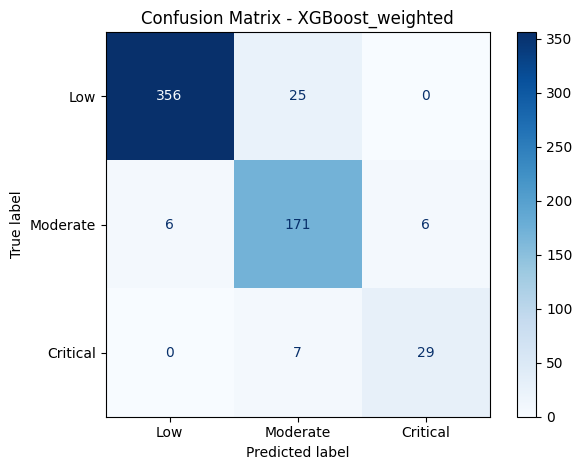

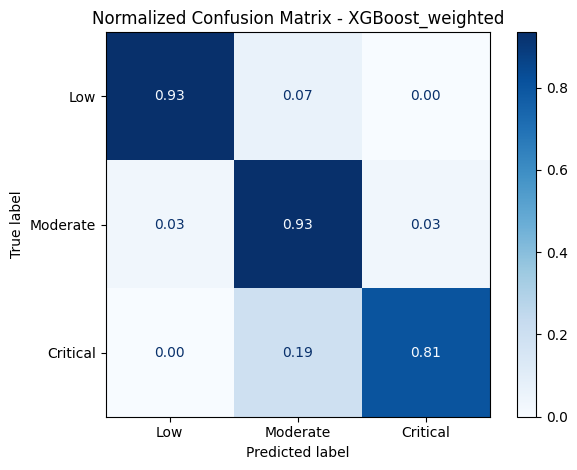

In [19]:

cm = confusion_matrix(y_test_eval, y_pred, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_order
)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


cm_norm = confusion_matrix(y_test_eval, y_pred, labels=[0, 1, 2], normalize="true")

disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=label_order
)
disp_norm.plot(cmap="Blues", values_format=".2f")
plt.title(f"Normalized Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("normalized_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()



Creates a per-class evaluation chart from the classification report and saves the full report for analysis.

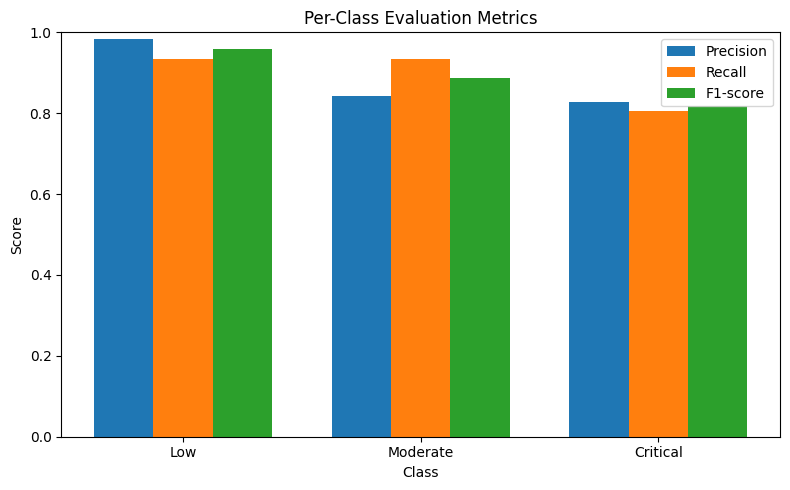

Saved: classification_report_full.csv


In [20]:

report = classification_report(
    y_test_eval,
    y_pred,
    labels=[0, 1, 2],
    target_names=label_order,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df_classes = report_df.loc[label_order, ["precision", "recall", "f1-score"]]

x = np.arange(len(label_order))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, report_df_classes["precision"], width=width, label="Precision")
plt.bar(x, report_df_classes["recall"], width=width, label="Recall")
plt.bar(x + width, report_df_classes["f1-score"], width=width, label="F1-score")
plt.xticks(x, label_order)
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Per-Class Evaluation Metrics")
plt.legend()
plt.tight_layout()
plt.savefig("classification_report_chart.png", dpi=300, bbox_inches="tight")
plt.show()

report_df.to_csv("classification_report_full.csv", index=True)
print("Saved: classification_report_full.csv")



Plots the distribution of prediction confidence scores to show how certain the model is about its test predictions.

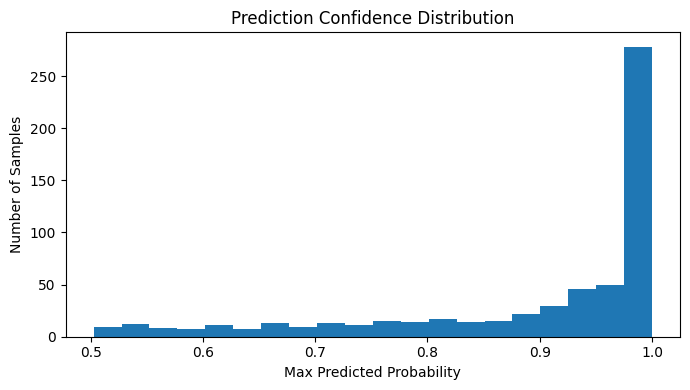

In [21]:

if test_proba is not None:
    pred_conf = np.max(test_proba, axis=1)

    plt.figure(figsize=(7, 4))
    plt.hist(pred_conf, bins=20)
    plt.title("Prediction Confidence Distribution")
    plt.xlabel("Max Predicted Probability")
    plt.ylabel("Number of Samples")
    plt.tight_layout()
    plt.savefig("prediction_confidence_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()



Plots one-vs-rest ROC curves for each priority class to evaluate the model’s probability-based discrimination performance.

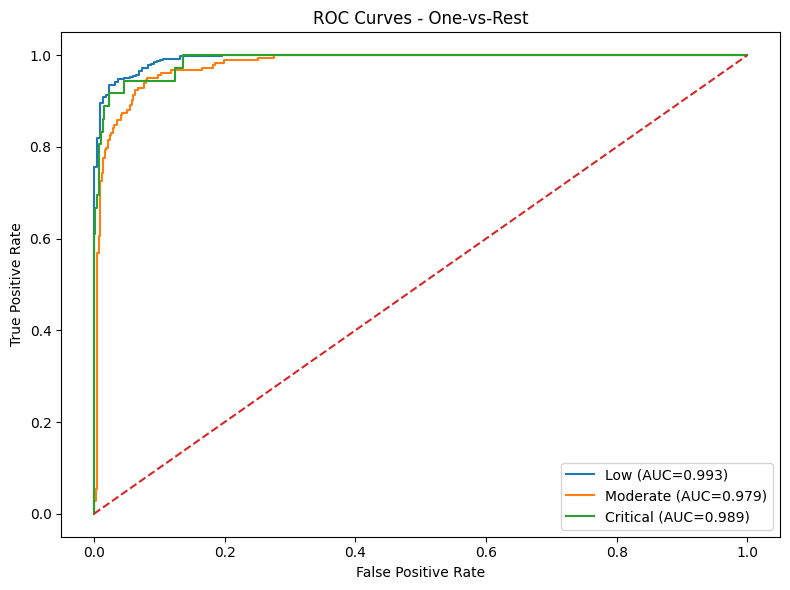

In [22]:

if test_proba is not None:
    y_test_bin = label_binarize(y_test_eval, classes=[0, 1, 2])

    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(label_order):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves - One-vs-Rest")
    plt.legend()
    plt.tight_layout()
    plt.savefig("roc_curves_multiclass.png", dpi=300, bbox_inches="tight")
    plt.show()



Plots one-vs-rest precision–recall curves for each priority class to assess probability-based performance under class imbalance.

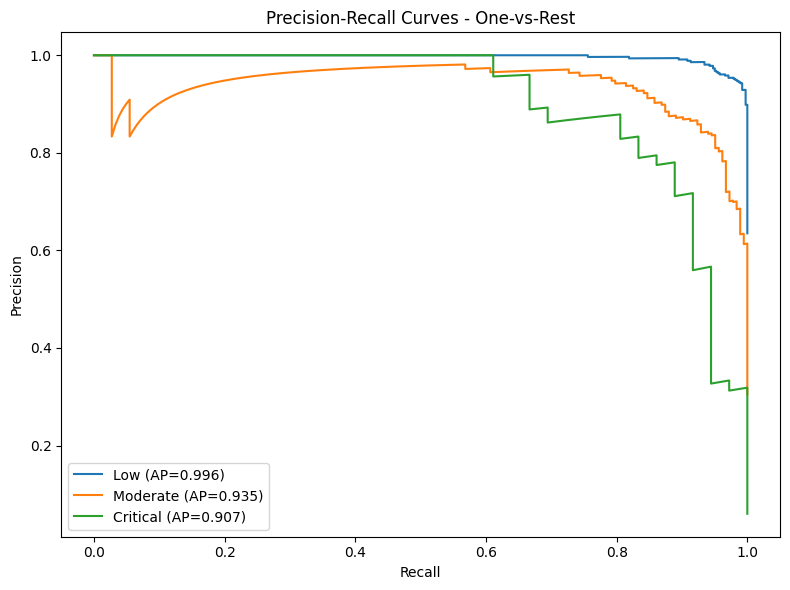

In [23]:

if test_proba is not None:
    y_test_bin = label_binarize(y_test_eval, classes=[0, 1, 2])

    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(label_order):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], test_proba[:, i])
        ap = average_precision_score(y_test_bin[:, i], test_proba[:, i])
        plt.plot(recall, precision, label=f"{class_name} (AP={ap:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves - One-vs-Rest")
    plt.legend()
    plt.tight_layout()
    plt.savefig("precision_recall_curves_multiclass.png", dpi=300, bbox_inches="tight")
    plt.show()



Calculates and visualizes the most important features influencing the final priority prediction model

In [24]:

print("\nCalculating Feature Importance...")

try:
    if best_is_catboost_native:
        fi = pd.DataFrame({
            "feature": X_catboost.columns,
            "importance": best_pipe.get_feature_importance()
        }).sort_values("importance", ascending=False)

    else:
        result = permutation_importance(
            best_pipe,
            X_test,
            y_test,
            n_repeats=10,
            random_state=42,
            n_jobs=-1
        )
        fi = pd.DataFrame({
            "feature": X.columns,
            "importance": result.importances_mean
        }).sort_values("importance", ascending=False)

    print("\nTop Important Features:")
    print(fi.head(15))

    fi.to_excel("feature_importance_full.csv", index=False, engine="openpyxl")
    fi_top = fi.head(15).copy()
    fi_top.to_excel("top_feature_importance.csv", index=False, engine="openpyxl")

    plt.figure(figsize=(9, 6))
    plt.barh(fi_top["feature"][::-1], fi_top["importance"][::-1])
    plt.title("Top 15 Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("top_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception as e:
    print("Feature importance could not be calculated:", e)




Calculating Feature Importance...

Top Important Features:
                       feature  importance
11                     trapped    0.139333
13              access_blocked    0.119500
18          vulnerability_flag    0.115333
1                   num_people    0.078333
7            water_rising_flag    0.053833
16        building_damage_flag    0.052833
9   landslide_active_risk_flag    0.051833
15             river_near_flag    0.050167
12        medical_urgency_flag    0.028500
14         river_overflow_flag    0.025167
10    cyclone_active_risk_flag    0.024500
2                duration_band    0.019333
8          near_submerged_flag    0.014833
3                     children    0.013833
4                      elderly    0.013500
Feature importance could not be calculated: Invalid extension for engine '<property object at 0x7f80e304d580>': 'csv'


Performs a label-shuffle leakage test to confirm that the priority model’s accuracy comes from real feature-label patterns rather than data leakage.


Running leakage test (label shuffle)...
Accuracy after label shuffle: 0.365


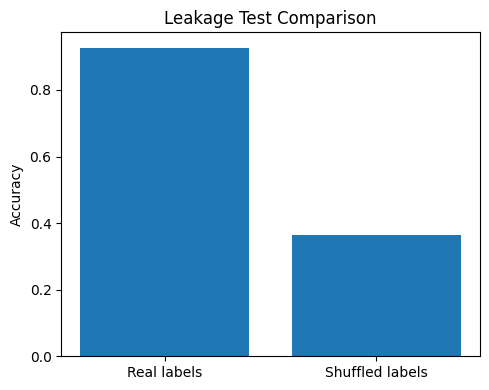

In [25]:

print("\nRunning leakage test (label shuffle)...")

if best_is_catboost_native:
    y_shuffled = np.random.permutation(y_train_cb)

    leak_model = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="MultiClass",
        auto_class_weights="Balanced",
        verbose=0,
        random_seed=42
    )
    leak_model.fit(X_train_cb, y_shuffled, cat_features=cat_feature_indices)
    shuffle_pred = leak_model.predict(X_test_cb).reshape(-1).astype(int)
    shuffle_acc = accuracy_score(y_test_cb, shuffle_pred)

else:
    y_shuffled = np.random.permutation(y_train)
    leak_model = clone(models[best_model_name])
    leak_model.fit(X_train, y_shuffled)
    shuffle_pred = leak_model.predict(X_test)
    shuffle_acc = accuracy_score(y_test, shuffle_pred)

real_acc = accuracy_score(y_test_eval, y_pred)

print("Accuracy after label shuffle:", shuffle_acc)

plt.figure(figsize=(5, 4))
plt.bar(["Real labels", "Shuffled labels"], [real_acc, shuffle_acc])
plt.ylabel("Accuracy")
plt.title("Leakage Test Comparison")
plt.tight_layout()
plt.savefig("leakage_test_comparison.png", dpi=300, bbox_inches="tight")
plt.show()



Trains the final priority prediction model on the full training data and saves the model, class scalers, label mapping, and feature columns for deployment.

In [26]:



if best_model_name == "CatBoost_native_balanced":
    final_model = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="MultiClass",
        auto_class_weights="Balanced",
        verbose=0,
        random_seed=42
    )
    final_model.fit(X_train_full_cb, y_train_full_cb, cat_features=cat_feature_indices)

elif best_model_name == "XGBoost_weighted":

    final_model = Pipeline([
        ("prep", preprocess_tree),
        ("clf", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        ))
    ])

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train_full
    )

    final_model.fit(
        X_train_full,
        y_train_full,
        clf__sample_weight=sample_weights
    )

elif best_model_name == "LightGBM_weighted":

    final_model = Pipeline([
        ("prep", preprocess_tree),
        ("clf", LGBMClassifier(
            objective="multiclass",
            num_class=3,
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ))
    ])
    final_model.fit(X_train_full, y_train_full)

elif best_model_name == "HistGradientBoosting_weighted":

    final_model = Pipeline([
        ("prep", preprocess_tree),
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=5,
            max_iter=250,
            random_state=42
        ))
    ])

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train_full
    )

    final_model.fit(
        X_train_full,
        y_train_full,
        clf__sample_weight=sample_weights
    )

else:
    final_model = clone(models[best_model_name])
    final_model.fit(X_train_full, y_train_full)

joblib.dump(final_model, "best_priority_model_3stage.joblib")
joblib.dump(best_scalers, "best_class_scalers_3stage.joblib")
joblib.dump(label_to_int, "priority_label_mapping_3stage.joblib")
joblib.dump(X.columns.tolist(), "priority_feature_columns.joblib")

print("\nFinal model saved: best_priority_model_3stage.joblib")
print("Class scalers saved: best_class_scalers_3stage.joblib")
print("Label mapping saved: priority_label_mapping_3stage.joblib")
print("Feature columns saved: priority_feature_columns.joblib")


Final model saved: best_priority_model_3stage.joblib
Class scalers saved: best_class_scalers_3stage.joblib
Label mapping saved: priority_label_mapping_3stage.joblib
Feature columns saved: priority_feature_columns.joblib


In [27]:

summary_results = pd.DataFrame([{
    "best_model": best_model_name,
    "test_accuracy": accuracy_score(y_test_eval, y_pred),
    "test_balanced_accuracy": balanced_accuracy_score(y_test_eval, y_pred),
    "test_f1_macro": f1_score(y_test_eval, y_pred, average="macro"),
    "test_f1_weighted": f1_score(y_test_eval, y_pred, average="weighted"),
    "shuffle_accuracy": shuffle_acc,
    "best_scaler_low": best_scalers[0],
    "best_scaler_moderate": best_scalers[1],
    "best_scaler_critical": best_scalers[2]
}])

summary_results.to_csv("final_test_results_summary.csv", index=False)
print("Saved: final_test_results_summary.csv")


predictions_df = pd.DataFrame({
    "actual": [int_to_label[v] for v in y_test_eval],
    "predicted": [int_to_label[v] for v in y_pred]
})

if test_proba is not None:
    predictions_df["proba_low"] = test_proba[:, 0]
    predictions_df["proba_moderate"] = test_proba[:, 1]
    predictions_df["proba_critical"] = test_proba[:, 2]
    predictions_df["max_confidence"] = np.max(test_proba, axis=1)

predictions_df.to_csv("test_predictions_with_probabilities.csv", index=False)
print("Saved: test_predictions_with_probabilities.csv")

Saved: final_test_results_summary.csv
Saved: test_predictions_with_probabilities.csv


In [28]:
import zipfile
from google.colab import files

files_to_download = [
    "best_priority_model_3stage.joblib",
    "best_class_scalers_3stage.joblib",
    "priority_label_mapping_3stage.joblib"
]

with zipfile.ZipFile("priority_model.zip", "w") as z:
    for f in files_to_download:
        z.write(f)

files.download("priority_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>